<a href="https://colab.research.google.com/github/MohitVerma0098/6thSem-ML-Lab/blob/main/1BM23CS198_LAB_9_KMEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


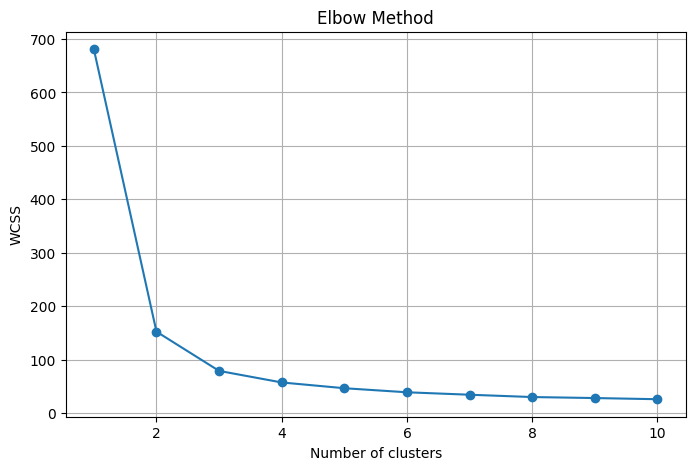

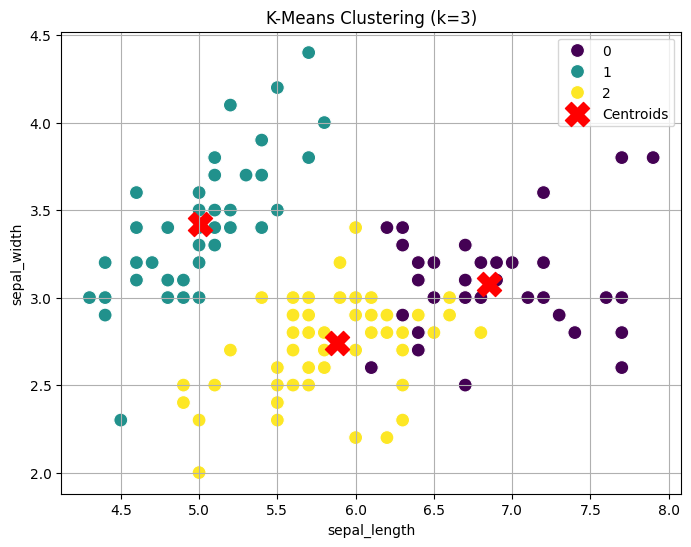

Cluster count:
cluster
2    61
1    50
0    39
Name: count, dtype: int64


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load dataset (SAFE)
# -----------------------------
try:
    df = pd.read_csv('/content/iris (2) (2).csv')
except FileNotFoundError:
    print("Error: File not found!")
    # Removed exit() to allow subsequent code to gracefully fail or be handled
    # In a notebook, exit() can sometimes terminate the kernel or stop execution abruptly
    # without clear error messages for the user.

print(df.head())
print(df.columns)

# -----------------------------
# Select features
# -----------------------------
feature_columns = ['sepal length (cm)', 'sepal width (cm)',
                   'petal length (cm)', 'petal width (cm)']

if all(col in df.columns for col in feature_columns):
    X = df[feature_columns].copy()
else:
    # fallback option
    X = df.select_dtypes(include=['number']).copy()

# -----------------------------
# Elbow Method
# -----------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

# -----------------------------
# Apply KMeans (k=3)
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels to original dataset
df['cluster'] = clusters

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1],
                hue=clusters, palette='viridis', s=100)

# Centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=300, c='red', marker='X', label='Centroids')

plt.title('K-Means Clustering (k=3)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Output
# -----------------------------
print("Cluster count:")
print(df['cluster'].value_counts())